<a href="https://colab.research.google.com/github/ricvazquez/ColabFiles/blob/main/T03_Sem06_Probabilidades_273509.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Taller aplicado de Probabilidades
## ¿Debemos desplegar el nuevo modelo de IA?

**Contexto.** Una empresa de e-commerce desarrolló un modelo para detectar fraude en transacciones. Antes de desplegarlo, el equipo debe cuantificar el riesgo y analizar algunos fenómenos probabilísticos asociados con su funcionamiento.

### Indicaciones

- Este taller **no evalúa programación en Python**.
- Completa únicamente las líneas marcadas con `# TODO`.
- En los `TODO` se pide escribir **expresiones matemáticas sencillas en Python** o usar una función ya proporcionada.
- **No modifiques** el código de simulación, visualización ni las funciones auxiliares.
- Ejecuta las celdas en orden.
- Escribe tus respuestas e interpretaciones en los espacios indicados.


In [ ]:
# Configuración
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scipy.stats as st
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

np.random.seed(42)



### Simulación de datos

Las variables utilizadas son:

- `fraud`: la transacción es fraude (`1`) o no (`0`).
- `amount`: monto de la transacción.
- `customer_segment`: segmento del cliente (`new`, `frequent`, `premium`).
- `score_old`: puntuación producida por el modelo anterior.
- `score_new`: puntuación producida por el modelo nuevo.


In [ ]:
# Simulación de datos de transacciones con fraude
def simulate_transactions(n=20000, base_fraud_rate=0.04):
    segments = np.random.choice(
        ["new", "frequent", "premium"],
        size=n,
        p=[0.45, 0.45, 0.10]
    )

    seg_fraud_rate = {
        "new": 0.055,
        "frequent": 0.030,
        "premium": 0.020
    }

    fraud = np.array(
        [np.random.rand() < seg_fraud_rate[s] for s in segments]
    ).astype(int)

    mu = np.where(
        segments == "premium",
        4.5,
        np.where(segments == "frequent", 4.0, 3.8)
    )
    sigma = 0.6
    amount = np.random.lognormal(mean=mu, sigma=sigma)

    z_amount = (
        np.log(amount) - np.mean(np.log(amount))
    ) / np.std(np.log(amount))

    base = 0.4 * z_amount + np.random.normal(0, 1.0, size=n)

    shift_old = 1.2
    shift_new = 1.5

    raw_old = (
        base
        + shift_old * fraud
        + np.random.normal(0, 0.3, size=n)
    )
    raw_new = (
        base
        + shift_new * fraud
        + np.random.normal(0, 0.3, size=n)
    )

    score_old = 1 / (1 + np.exp(-raw_old))
    score_new = 1 / (1 + np.exp(-raw_new))

    return pd.DataFrame({
        "fraud": fraud,
        "amount": amount,
        "customer_segment": segments,
        "score_old": score_old,
        "score_new": score_new
    })

df = simulate_transactions()

print("Primeras observaciones:")
display(df.head())

print("\nProporción simulada de fraude:")
display(df["fraud"].mean())


Primeras observaciones:


,fraud,amount,customer_segment,score_old,score_new
0,0,31.809977,new,0.188175,0.213420
1,0,76.031836,premium,0.911353,0.927406
2,0,49.301270,frequent,0.394756,0.521290
3,0,48.452939,frequent,0.207853,0.224628
4,0,30.357732,new,0.299676,0.395620



Proporción simulada de fraude:


np.float64(0.0402)

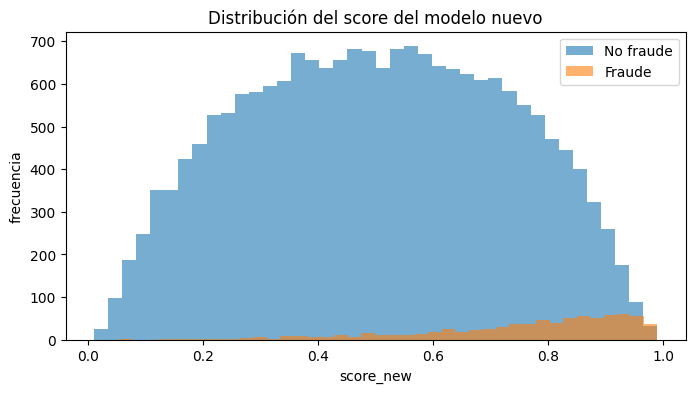

In [ ]:
# Visualización inicial
fig = plt.figure(figsize=(8, 4))
plt.hist(
    df.loc[df["fraud"] == 0, "score_new"],
    bins=40,
    alpha=0.6,
    label="No fraude"
)
plt.hist(
    df.loc[df["fraud"] == 1, "score_new"],
    bins=40,
    alpha=0.6,
    label="Fraude"
)
plt.title("Distribución del score del modelo nuevo")
plt.xlabel("score_new")
plt.ylabel("frecuencia")
plt.legend()
plt.show()



---
## 1) Probabilidad condicional y Regla de Bayes

Definimos los eventos:

- $ F$: la transacción es fraude.
- $D$: el modelo genera una alerta de fraude.

Usaremos:

$$
P(F)=0.04,\qquad
P(D\mid F)=0.92,\qquad
P(D\mid \neg F)=0.08.
$$

### Actividades

1. Calcula $P(\neg F)$.
2. Calcula $P(D)$ mediante la ley de la probabilidad total.
3. Calcula $P(F\mid D)$ usando Bayes.
4. Interpreta $P(F\mid D)$: si el modelo genera una alerta, ¿qué nos dice ese valor?
5. Para 100,000 transacciones, calcula cuántas alertas procederían de fraudes reales y cuántas serían falsas alertas.

Completa solamente las expresiones indicadas en la siguiente celda.


In [ ]:
# Parámetros del escenario
P_F = 0.04
P_D_given_F = 0.92
P_D_given_notF = 0.08

# Completa las expresiones matemáticas
P_notF = 1 - P_F          # TODO: probabilidad de que NO sea fraude
P_D = (P_D_given_F * P_F) + (P_D_given_notF * P_notF)           # TODO: probabilidad total de que el modelo genere una alerta
P_F_given_D = (P_D_given_F * P_F) / P_D     # TODO: probabilidad de fraude dado que hubo alerta


In [ ]:
# Mostrar los resultados calculados
print(f"P(no fraude) = {P_notF}")
print(f"P(alerta) = {P_D}")
print(f"P(fraude | alerta) = {P_F_given_D}")


P(no fraude) = 0.96
P(alerta) = 0.11359999999999999
P(fraude | alerta) = 0.323943661971831



### Interpretación
**1.1. Interpreta $P(F\mid D)$ en el contexto del equipo que revisa alertas.**

>Respuesta:
>Esto es la probabilidad de que la transaccion sea fraude, dado que el modelo haya generado una alerta, lo cual nos dice que el modelo tiene un bajo rate en cuanto a que todas las alertas vayan a ser fraudes, siendo que si al dia salen 10 de alarmas, menos de 4 van a ser fraudes

>


In [ ]:
# Interpretación con números absolutos
N = 100_000

expected_fraud = N *P_F        # TODO: número esperado de transacciones fraudulentas
expected_notfraud = N * P_notF       # TODO: número esperado de transacciones no fraudulentas

alerts_from_fraud = expected_fraud * P_D_given_F       # TODO: alertas procedentes de fraudes reales
alerts_from_notfraud = expected_notfraud * P_D_given_notF    # TODO: alertas procedentes de transacciones no fraudulentas

total_alerts = alerts_from_fraud + alerts_from_notfraud            # TODO: total esperado de alertas


In [ ]:
# Mostrar resultados
print(f"Fraudes esperados: {expected_fraud}")
print(f"No fraudes esperados: {expected_notfraud}")
print(f"Alertas verdaderas: {alerts_from_fraud}")
print(f"Alertas falsas: {alerts_from_notfraud}")
print(f"Alertas totales: {total_alerts}")


Fraudes esperados: 4000.0
No fraudes esperados: 96000.0
Alertas verdaderas: 3680.0
Alertas falsas: 7680.0
Alertas totales: 11360.0


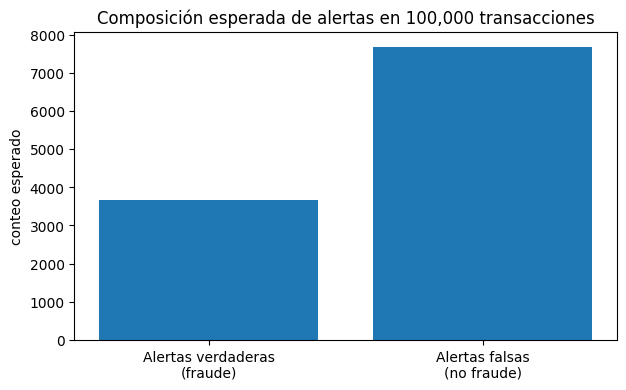

In [ ]:
# Visualización: composición esperada de las alertas
labels = ["Alertas verdaderas\n(fraude)", "Alertas falsas\n(no fraude)"]
values = [alerts_from_fraud, alerts_from_notfraud]

fig = plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.title("Composición esperada de alertas en 100,000 transacciones")
plt.ylabel("conteo esperado")
plt.show()



**1.2. ¿Qué observas en la composición de las alertas? ¿Por qué puede haber muchas falsas alertas aunque $P(D\mid F)$ sea alto?**

>Respuesta: Porque aunque la probabilidad de que haya una alerta dado que haya una fraude es muy alta, la probabilidad de que haya un fraude dado que hubo una alerta no son tan altas, y es lo que se muestra en la grafica. Dado que la probabilidad es de 32, podemos decir que por cada 10 alertas menos de 4 son alertas reales
>


---
## 2) Distribución Binomial: evaluación del rendimiento

Supongamos que evaluamos el modelo en $n$ transacciones que sabemos que son fraudulentas.

Si la probabilidad de detectar correctamente un fraude es $p$, entonces:

$$
X\sim\operatorname{Binomial}(n,p),
$$

donde $X$ es el número de fraudes detectados correctamente.

Usaremos:

$$
n=500,\qquad p=0.92.
$$

### Actividades

1. Calcula $P(X\geq470)$.
2. Observa la gráfica y comenta qué representa el umbral $470$.


In [ ]:
# Función auxiliar: NO modificar
def binom_tail_prob(n, p, k0):
    """Calcula P(X >= k0) para X~Binomial(n,p)."""
    if SCIPY_OK:
        return st.binom.sf(k0 - 1, n, p)

    mu = n * p
    sigma = math.sqrt(n * p * (1 - p))
    z = ((k0 - 0.5) - mu) / sigma
    Phi = 0.5 * (1 + math.erf(z / math.sqrt(2)))
    return 1 - Phi


In [ ]:
# Calcula P(X >= 470) para X~Binomial(n=500, p=0.92)

prob_ge_470 = binom_tail_prob(500, 0.92, 470)   # TODO: usa binom_tail_prob(n, p, k0)

# Mostrar resultado
print(f"P(X >= 470) = {prob_ge_470}")


P(X >= 470) = 0.054261021841918375


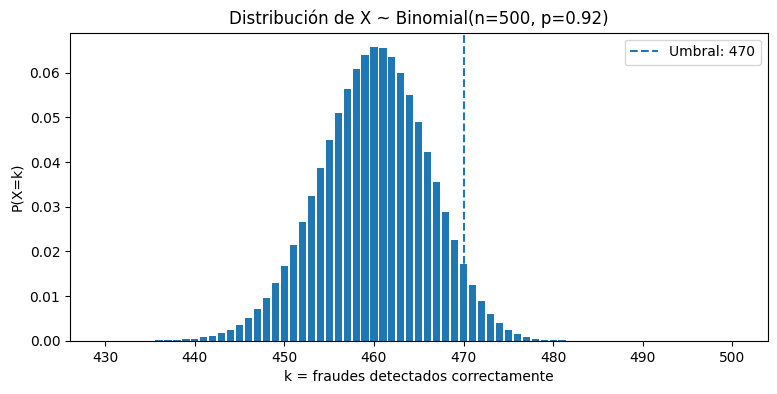

In [ ]:
# Visualización de la PMF: NO modificar
k = np.arange(430, 501)
n=500
p=0.92

if SCIPY_OK:
    pmf = st.binom.pmf(k, n, p)
else:
    mu = n * p
    sigma = math.sqrt(n * p * (1 - p))
    pmf = np.exp(-0.5 * ((k - mu) / sigma) ** 2)
    pmf = pmf / pmf.sum()

fig = plt.figure(figsize=(9, 4))
plt.bar(k, pmf)
plt.axvline(470, linestyle="--", label="Umbral: 470")
plt.title("Distribución de X ~ Binomial(n=500, p=0.92)")
plt.xlabel("k = fraudes detectados correctamente")
plt.ylabel("P(X=k)")
plt.legend()
plt.show()



### Respuestas

**2.1. Interpreta $P(X\geq470)$ en el contexto del modelo.**

>Respuesta: La probabilidad de tener 470 aciertos en 500 intentos es baja considerando que la probabilidad es de 92%, lo cual nos diria que de 500 intentos, la probabilidad de exito son 460, por lo visto el aumentar solo 10 mas cambia totalmente la probabilidad de que suceda
>
<br><br><br>

**2.2. Observa la gráfica. ¿Dónde se encuentra 470 respecto al centro de la distribución y qué sugiere esto?**

>Respuesta:
>Como se ve en la grafica el 470 esta muy cerca de la distribucion, ya que el numero esperado es 460, por eso aun hay probabilidad de que pudiera pasar
<br><br><br>


---
## 3) Distribución de Poisson: carga operacional por hora

Supongamos que el número de intentos de fraude por hora puede modelarse mediante una distribución de Poisson:

$$
X\sim\operatorname{Poisson}(\lambda),
\qquad \lambda=12.
$$

Aquí $X$ representa el número de fraudes en una hora.

### Actividades

1. Calcula $P(X=20)$.
2. Calcula $P(X\geq20)$.
3. Observa la PMF y comenta qué tan inusual parece observar 20 o más fraudes en una hora.


In [ ]:
lambda_poisson = 12

# Funciones auxiliares: NO modificar
def poisson_pmf(lam, k):
    if SCIPY_OK:
        return st.poisson.pmf(k, lam)
    return math.exp(-lam) * (lam ** k) / math.factorial(k)

def poisson_tail(lam, k0):
    """Calcula P(X >= k0)."""
    if SCIPY_OK:
        return st.poisson.sf(k0 - 1, lam)
    return sum(poisson_pmf(lam, k) for k in range(k0, 200))


In [ ]:
p_eq_20 = poisson_pmf(12,20)   # TODO: P(X=20) usa poisson_pmf(lam, k)
p_ge_20 = poisson_tail(12, 20)   # TODO: P(X>=20) usa poisson_tail(lam, k)

# Mostrar resultados
print(f"P(X = 20) = {p_eq_20}")
print(f"P(X >= 20) = {p_ge_20}")

P(X = 20) = 0.00968203216821916
P(X >= 20) = 0.02127976938302662


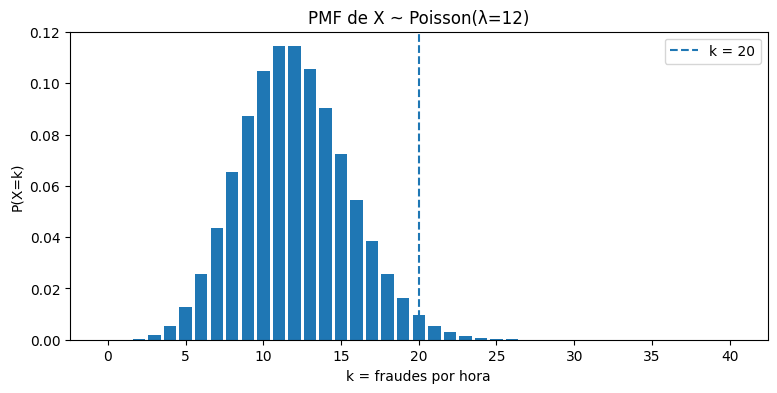

In [ ]:
# Visualización de la PMF: NO modificar
k = np.arange(0, 41)
pmf = np.array([poisson_pmf(lambda_poisson, int(kk)) for kk in k])

fig = plt.figure(figsize=(9, 4))
plt.bar(k, pmf)
plt.axvline(20, linestyle="--", label="k = 20")
plt.title("PMF de X ~ Poisson(λ=12)")
plt.xlabel("k = fraudes por hora")
plt.ylabel("P(X=k)")
plt.legend()
plt.show()



### Respuestas

**1. Interpreta $P(X=20)$.**

>Respuesta:
>La probabilidad de que la alerta suceda 20 veces en una hora es sumamente baja, tan solo de un 0.97% ya que el intervalo dado es 12, 20 es un numero que esta muy lejos
<br><br><br>

**2. ¿Cuál es la diferencia conceptual entre $P(X=20)$ y $P(X\geq20)$?**

>Respuesta:
> Los rangos, ya que cuando decimos que X = 20, solo estamos considerando un valor, en cambio si decimos que X>=20 estamos considerando de 20 en adelante que al ser mas opciones aaumenta un poco la probabilidad a 2% que tampoco es mucha
<br><br><br>

**3. A partir de la gráfica y del valor calculado, ¿considerarías 20 o más fraudes en una hora un evento frecuente o poco frecuente? Justifica.**

>Respuesta:
>Con la grafica y con las probabilidades dadas, podemos decir que probabilidad de que haya 20 o mas fraudes es muy poco frecuente siendo menos del 3% de probabilidad
<br><br><br>



---
## 4) Distribución Geométrica: tiempo hasta detectar una señal

Un algoritmo analiza imágenes sucesivas e intenta detectar correctamente una señal.

Cada intento es independiente y tiene probabilidad:

$$
p=0.10
$$

de éxito.

Sea $X$ el número de intento en el que ocurre **el primer éxito**:

$$
X\sim\operatorname{Geom}(p).
$$

Usamos la convención:

$$
P(X=k)=(1-p)^{k-1}p,
\qquad k=1,2,\ldots
$$

### Actividades

1. Calcula $P(X=4)$.
2. Calcula $P(X\leq4)$.
3. Compara ambas probabilidades con una simulación de 10,000 corridas.
4. Interpreta la diferencia entre “éxito exactamente en el cuarto intento” y “éxito a más tardar en el cuarto intento”.


In [ ]:
p_geom = 0.10

def geom_pmf(p, k):
    """P(X=k) para la convención X = intento del primer éxito."""
    return (1 - p) ** (k - 1) * p


In [ ]:
p_x4 = geom_pmf(0.10, 4)     # TODO: P(X=4)
p_le_4 = geom_pmf(0.10, 4) + geom_pmf(0.10, 3) + geom_pmf(0.10, 2) + geom_pmf(0.10, 1)    # TODO: P(X<=4)

# Mostrar resultados teóricos
print(f"P(X = 4) = {p_x4}")
print(f"P(X <= 4) = {p_le_4}")


P(X = 4) = 0.0729
P(X <= 4) = 0.3439000000000001


In [ ]:
# Simulación: NO modificar
N_sim = 10_000
samples = np.random.geometric(p_geom, size=N_sim)

freq_x4 = np.mean(samples == 4)
freq_le_4 = np.mean(samples <= 4)

print("Resultados de la simulación:")
print(f"Frecuencia relativa de X=4: {freq_x4}")
print(f"Frecuencia relativa de X<=4: {freq_le_4}")

print("\nComparación teoría vs simulación:")
print(f"P(X=4) teórica: {p_x4} | simulada: {freq_x4}")
print(f"P(X<=4) teórica: {p_le_4} | simulada: {freq_le_4}")


Resultados de la simulación:
Frecuencia relativa de X=4: 0.072
Frecuencia relativa de X<=4: 0.3379

Comparación teoría vs simulación:
P(X=4) teórica: 0.0729 | simulada: 0.072
P(X<=4) teórica: 0.3439000000000001 | simulada: 0.3379


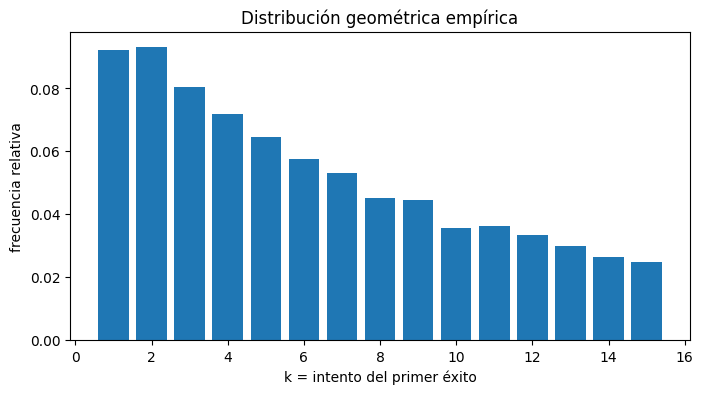

In [ ]:
# Visualización: histograma discreto de la simulación
vals, counts = np.unique(samples, return_counts=True)
pmf_emp = counts / N_sim

fig = plt.figure(figsize=(8, 4))
mask = vals <= 15
plt.bar(vals[mask], pmf_emp[mask])
plt.title("Distribución geométrica empírica")
plt.xlabel("k = intento del primer éxito")
plt.ylabel("frecuencia relativa")
plt.show()



### Respuestas

**4.1. Explica por qué $P(X=4)$ contiene tres fallos seguidos de un éxito.**

>Respuesta:
>Porque en esta probabilidad si importa el orden, a diferencia de la binomial donde no importaba que orden fuera, aqui si es importante que fallen las primeras 3 y en la 4ta haya un exito
<br><br><br>

**4.2. Explica qué significa $P(X\leq4)$.**

>Respuesta: Esta es la probabilidad de que el evento ocurra en la 4ta posibilidad o en alguna de las anteriores, lo cual si aumenta mucho la probabilidad ya que ahora si seria que pudiera ocurrir un exito en cualquiera de las 4 eventos
>
<br><br><br>

**4.3. ¿Los resultados simulados coinciden exactamente con los teóricos? ¿Deberían hacerlo?**

>Respuesta: Los resultados simulados son muy aproximados a los teoricos, y deberian serlo ya que ponen en practica la toeria
>
<br><br><br>

**4.4. ¿Cuál es la diferencia entre “detectar por primera vez en el cuarto intento” y “detectar a más tardar en el cuarto intento”?**

>Respuesta:
>Que en este metodo, el orden importa, si hablas de detectar en el 4to intento tu probabilidad se baja a 1 exito despues de 3 fracasos. En cambio si hablas de mas tardar al 4to intento, es la suma de las 4 psoibilidades
<br><br><br><br>



---
# Cierre

En este taller se trabajaron cuatro ideas:

- **Bayes:** actualizar una probabilidad después de observar evidencia.
- **Binomial:** contar éxitos en un número fijo de ensayos.
- **Poisson:** contar eventos en un intervalo.
- **Geométrica:** modelar el intento en el que ocurre el primer éxito.

Antes de entregar, verifica que:

- todas las líneas `# TODO` estén completas;
- todas las celdas se ejecuten en orden;
- las gráficas se generen correctamente;
- todas las preguntas tengan una respuesta escrita.
